In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# # Mostrar todas las columnas
pd.set_option("display.max_columns", None)

## Paso 1: Planteamiento del problema

>El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

## Paso 2: Exploración y limpieza de datos

In [3]:
archivo = "../data/raw/diabetes.csv"
df = pd.read_csv(archivo)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Paso 3: Análisis Descriptivo

In [4]:
df.shape

(768, 9)

## Paso 4: Limpieza de Datos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Limpieza de datos: Eliminar duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante

>No hay ningún dato que parezca irrelevante.

## Paso 5: Análisis de Variables

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


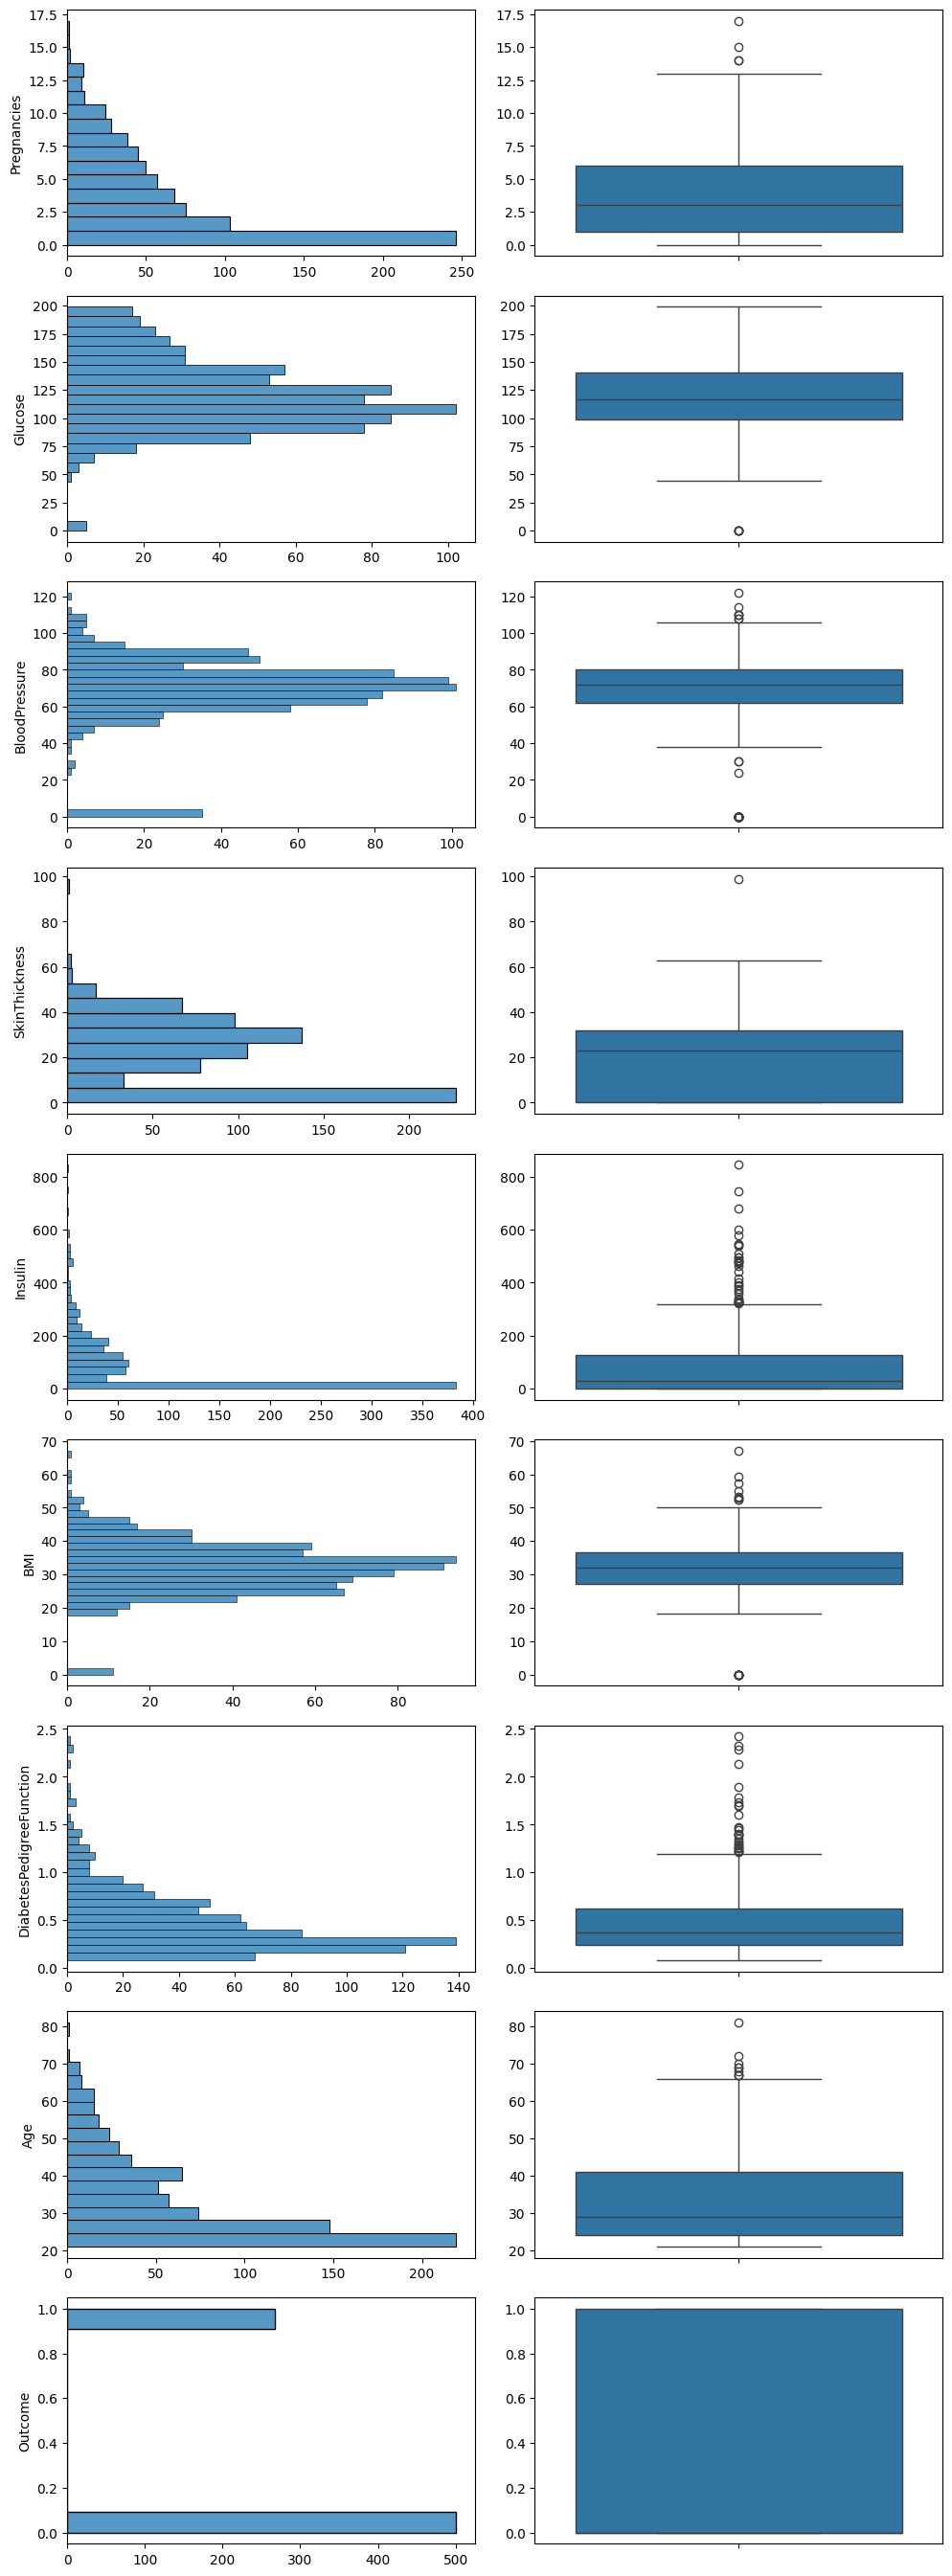

In [8]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()


fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

In [9]:
df_copy = df.copy(deep = True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

## showing the count of Nans
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
mediana = df_copy.median()
mediana

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                29.0000
Insulin                     125.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

In [11]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [12]:
df_copy['Glucose'] = df_copy['Glucose'].fillna(df_copy['Glucose'].mean())
df_copy['BloodPressure'] = df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean())
df_copy['SkinThickness'] = df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median())
df_copy['Insulin'] = df_copy['Insulin'].fillna(df_copy['Insulin'].median())
df_copy['BMI'] = df_copy['BMI'].fillna(df_copy['BMI'].median())

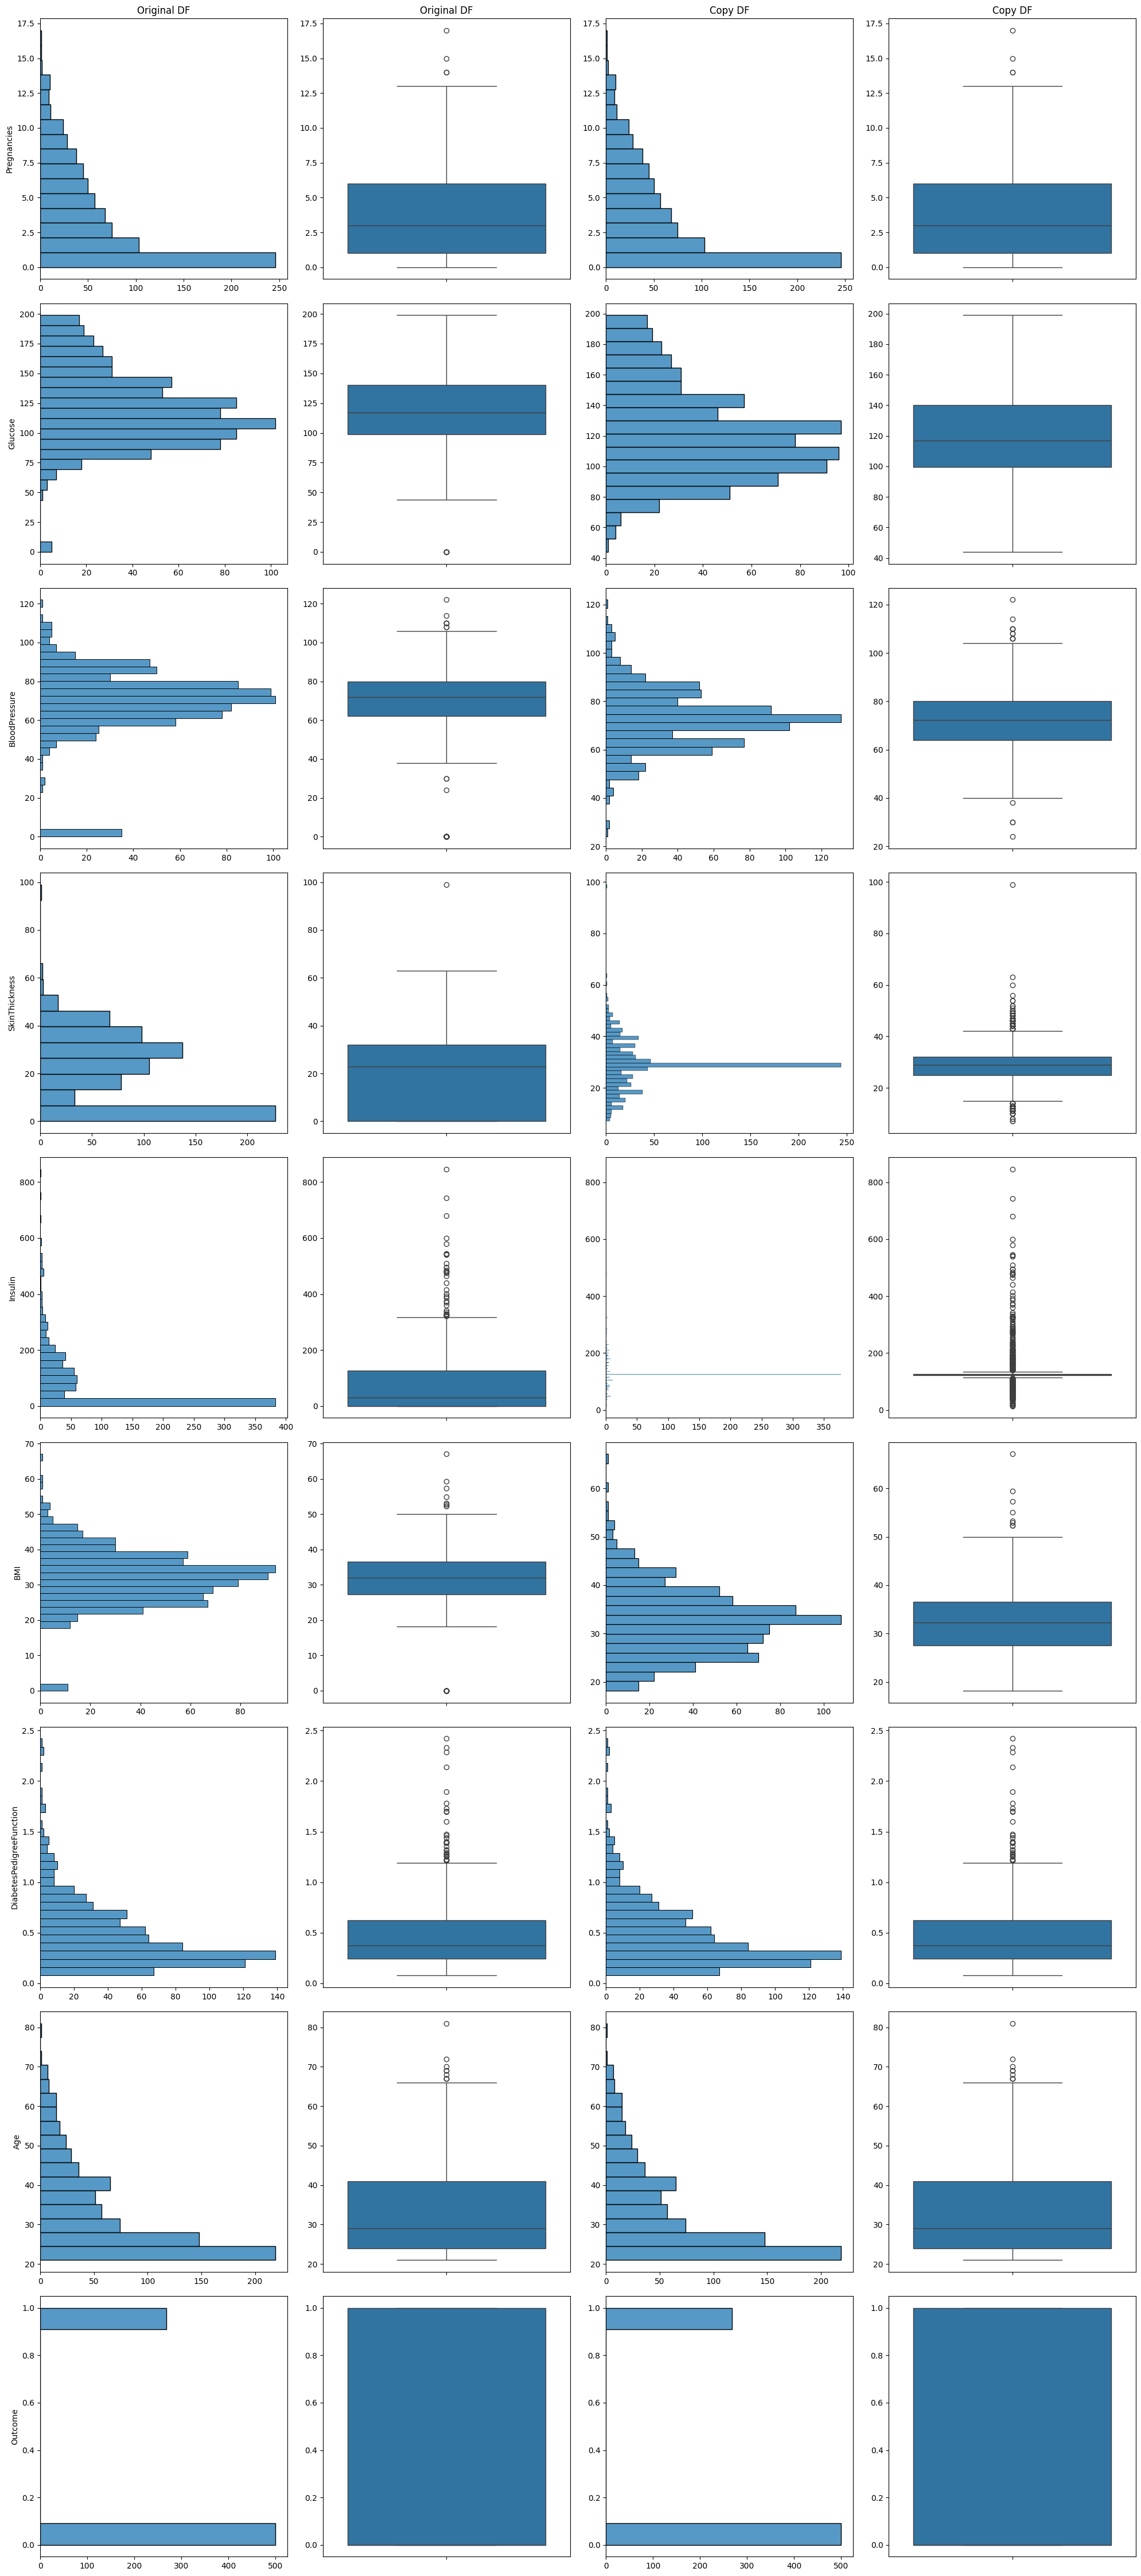

In [13]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()
foo = "Original DF"
bat = "Copy DF"

fig, axis = plt.subplots(len(num_variables), 4, figsize=(20, 5*len(num_variables)))
for i, var in enumerate(num_variables):
    if i > 0:
        foo = None
        bat = None    
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(title=foo, xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None, title=foo, xlabel=None)
    sns.histplot(ax=axis[i, 2], data=df_copy, y=var).set(title=bat, ylabel=None, xlabel=None)
    sns.boxplot(ax=axis[i, 3], data=df_copy, y=var).set(ylabel=None, title=bat, xlabel=None)


plt.tight_layout()
plt.show()

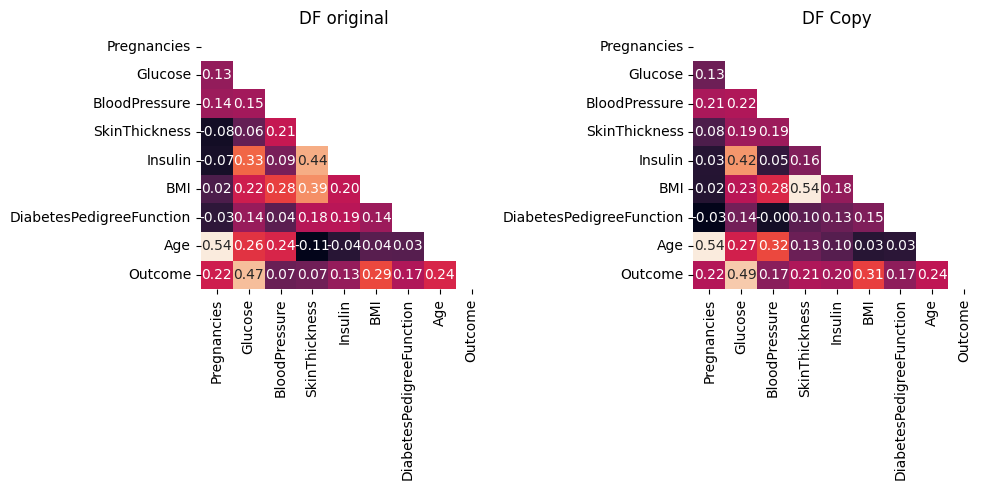

In [14]:
corr_y = df[num_variables].corr(numeric_only=True)
corr_copy_y = df_copy[num_variables].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_y, dtype=bool))
mask_copy_y = np.triu(np.ones_like(corr_copy_y, dtype=bool))
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(ax=axis[0], data=corr_y, annot=True, fmt=".2f", cbar=False, mask=mask)
axis[0].set_title("DF original")
sns.heatmap(ax=axis[1], data=corr_copy_y, annot=True, fmt=".2f", cbar=False, mask=mask_copy_y)
axis[1].set_title("DF Copy")

plt.tight_layout()
plt.show()

In [15]:
df_copy.to_csv("/workspaces/AnthonnyMal-Machine-Learnig/data/processed/df_diabetes", index=False)